# import required modules 

In [7]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model 
# define data csv to be read
df= pd.read_csv("Downloads/AB_NYC_2019_cleaned.csv")

# preview dataset
df.head()

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_review,log_price,availability_ratio,is_multi_host,has_reviews
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,438.0,5.010635,1.000000,1,1
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,224.0,5.420535,0.972603,1,1
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,226.0,5.017280,1.000000,0,0
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,179.0,4.499810,0.531507,0,1
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,407.0,4.394449,0.000000,0,1


In [8]:
# Define Target
y = df['log_price']

# Remove identifiers, target leakage
X = df.drop([
    'id',
    'host_id',
    'price',      # avoid leakage
    'log_price'   # target
], axis=1)

In [9]:
# Because we only have 5 neighbourhood groups we use One-Hot Encoding

X = pd.get_dummies(X, columns=['neighbourhood_group'], drop_first=False)
X = pd.get_dummies(X, columns=['room_type'], drop_first=False)

In [10]:
# Create mapping from neighbourhood to median log_price
# granular neighbourhood-level location was target encoded using median log price to capture local pricing dynamics without creating high-dimensional sparsity
neighbourhood_median = df.groupby('neighbourhood')['log_price'].median()

# Map values
X['neighbourhood_encoded'] = df['neighbourhood'].map(neighbourhood_median)

# Drop original column
X = X.drop('neighbourhood', axis=1)

In [11]:
# Train-test split
# test size is 20% of the sample (standard for linear regression modelling)
# A fixed random seed (random_state=42) was used to ensure reproducibility of the train-test split and clustering results
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
# Train the linear regression model 

from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [13]:
# Evaluate the model 

from sklearn.metrics import r2_score, mean_squared_error

y_pred = regr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", r2)
print("RMSE (log scale):", rmse)

R² Score: 0.5300533550953699
RMSE (log scale): 0.4750624179178898


In [14]:
#Train the final model 
from sklearn.linear_model import LinearRegression

regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [15]:
# Create Prediction Function

def predict_price(model, input_data, X_columns, neigh_median):

    # Convert input dictionary to DataFrame
    input_df = pd.DataFrame([input_data])

    # Target encode neighbourhood
    input_df['neighbourhood_encoded'] = input_df['neighbourhood'].map(neigh_median)

    # Drop original neighbourhood
    input_df = input_df.drop('neighbourhood', axis=1)

    # One-hot encode borough & room_type
    input_df = pd.get_dummies(input_df)

    # Align columns with training data
    input_df = input_df.reindex(columns=X_columns, fill_value=0)

    # Predict log price
    predicted_log_price = model.predict(input_df)

    # Convert back to real price
    predicted_price = np.expm1(predicted_log_price)

    return predicted_price[0]

In [16]:
# Example Input


new_listing = {
    'latitude': 40.75,
    'longitude': -73.98,
    'minimum_nights': 2,
    'number_of_reviews': 50,
    'reviews_per_month': 1.5,
    'calculated_host_listings_count': 1,
    'availability_ratio': 0.30,
    'days_since_review': 3,
    'is_multi_host': 0,
    'has_review': 1,
    'neighbourhood_group': 'Manhattan',
    'neighbourhood': 'Midtown',
    'room_type': 'Entire home/apt'
}

In [17]:
# Using the regression model built we get a preditction using the new listing input 
# X columns is using the column ordered defined previous step
# neigh median transforms input neighbourhood into log median price needed since we target encoded

predicted = predict_price(regr, new_listing, X.columns, neighbourhood_median)

print("Predicted Price: $", round(predicted, 2))

Predicted Price: $ 255.8


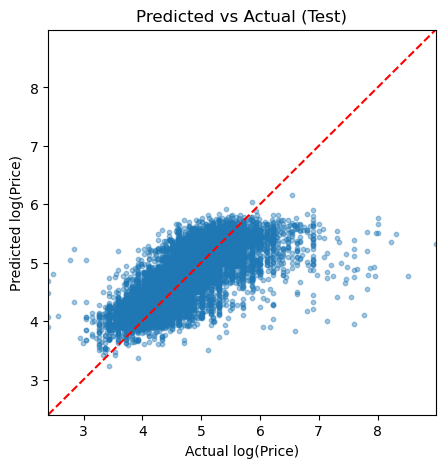

In [72]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.4, s=10)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Actual log(Price)'); plt.ylabel('Predicted log(Price)')
plt.title('Predicted vs Actual (Test)')
plt.show()


## Interpretation
Predictions closely follow the diagonal, indicating the model captures overall pricing patterns well. Some dispersion appears at higher values, suggesting mild under‑ or over‑prediction for expensive listings, but overall test performance is consistent and stable.

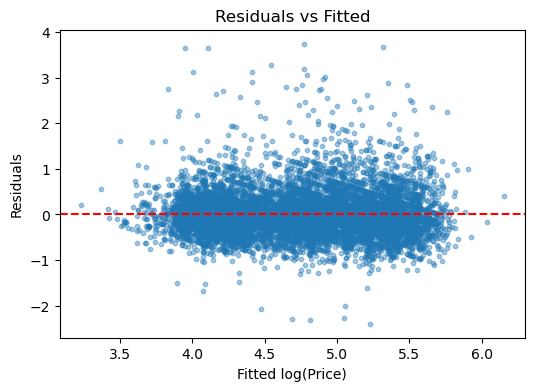

In [50]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.4, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted log(Price)'); plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()


## Interpretation 
Residuals are mostly centered around zero, indicating no major systematic bias. Slight spread at higher fitted values suggests increasing error for expensive listings, but the pattern overall shows stable variance and a reasonably well‑behaved model.

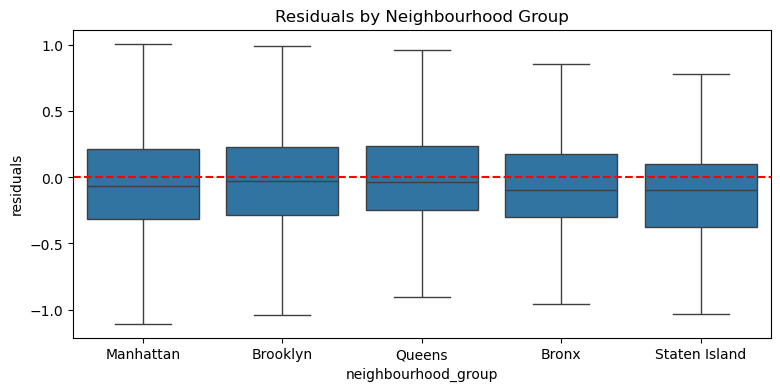

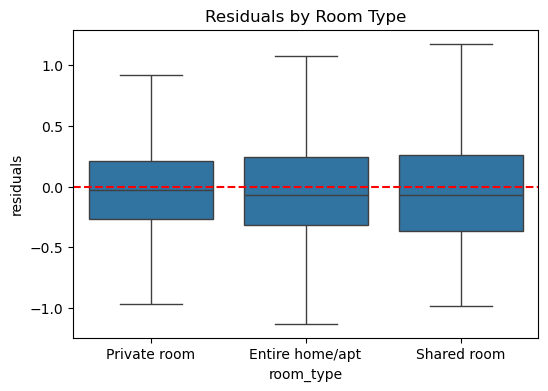

In [51]:
err_df = pd.DataFrame({'residuals': residuals, 
                       'neighbourhood_group': df.loc[y_test.index, 'neighbourhood_group'],
                       'room_type': df.loc[y_test.index, 'room_type']})

plt.figure(figsize=(9, 4))
sns.boxplot(x='neighbourhood_group', y='residuals', data=err_df, showfliers=False)
plt.title('Residuals by Neighbourhood Group'); plt.axhline(0, color='red', ls='--')
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x='room_type', y='residuals', data=err_df, showfliers=False)
plt.title('Residuals by Room Type'); plt.axhline(0, color='red', ls='--')
plt.show()


## interpretation
Residual patterns vary across neighbourhood groups and room types, indicating the model fits some segments better than others. Certain areas and room types show slight systematic under‑ or over‑prediction, suggesting location and accommodation type still hold nonlinear effects not fully captured by the model.

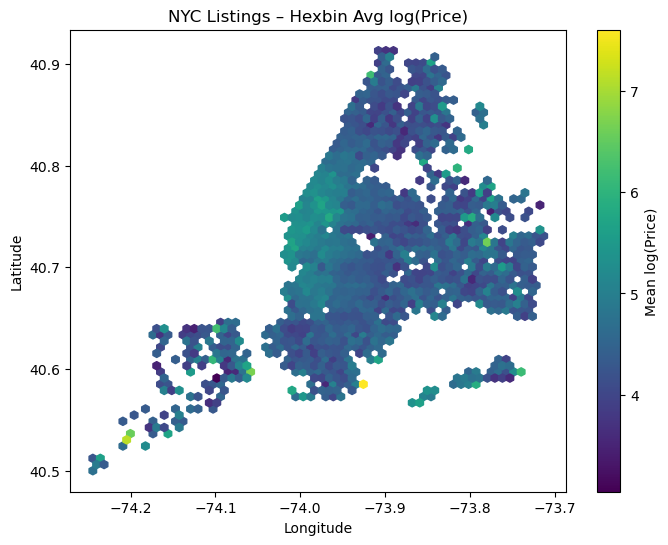

In [61]:
plt.figure(figsize=(8, 6))
hb = plt.hexbin(df['longitude'], df['latitude'],
                C=df['log_price'], gridsize=60, reduce_C_function=np.mean,
                cmap='viridis')
plt.colorbar(hb, label='Mean log(Price)')
plt.title('NYC Listings – Hexbin Avg log(Price)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.show()


## Interpretation
Higher prices cluster tightly in central Manhattan, with values dropping noticeably in outer boroughs. The hexbin map highlights clear geographic price gradients, showing Manhattan as the primary high‑value hotspot and other boroughs exhibiting uniformly lower averages.

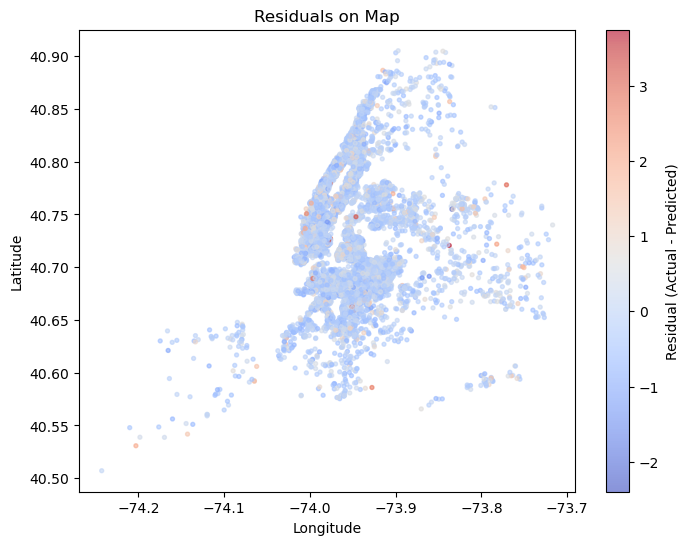

In [52]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(df.loc[y_test.index, 'longitude'],
                 df.loc[y_test.index, 'latitude'],
                 c=residuals, cmap='coolwarm', s=8, alpha=0.6)
plt.colorbar(sc, label='Residual (Actual - Predicted)')
plt.title('Residuals on Map')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.show()


## interpretation 
Residuals show geographic patterns: some areas consistently over‑ or under‑predict, indicating the model doesn’t fully capture localized price effects. Manhattan tends to produce higher positive or negative deviations, suggesting strong spatial heterogeneity still not modeled.

C:\Users\kapinga\AppData\Local\Temp\ipykernel_22884\2612352250.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef.head(top_k).values, y=coef.head(top_k).index, palette='viridis')


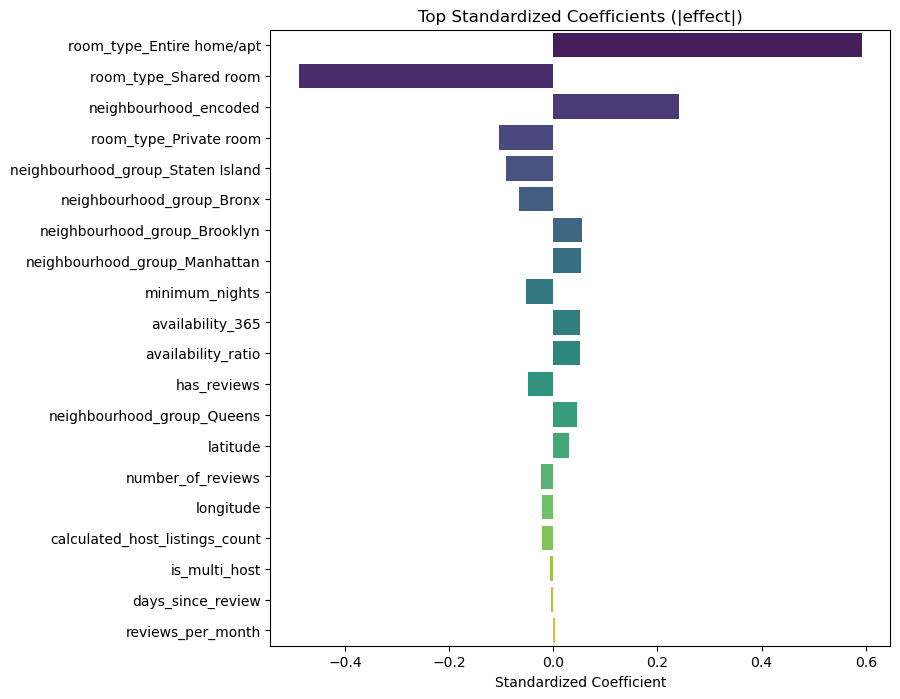

In [53]:
from sklearn.preprocessing import StandardScaler

num_cols_model = X.select_dtypes(include=[np.number]).columns.tolist()
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols_model] = scaler.fit_transform(X_train[num_cols_model])
X_test_scaled[num_cols_model] = scaler.transform(X_test[num_cols_model])

regr_std = LinearRegression().fit(X_train_scaled, y_train)
coef = pd.Series(regr_std.coef_, index=X_train_scaled.columns).sort_values(key=abs, ascending=False)

top_k = 20
plt.figure(figsize=(8, 8))
sns.barplot(x=coef.head(top_k).values, y=coef.head(top_k).index, palette='viridis')
plt.title('Top Standardized Coefficients (|effect|)')
plt.xlabel('Standardized Coefficient'); plt.ylabel('')
plt.show()


### Standardized coefficients highlight the most influential predictors on log‑price by magnitude. Positive coefficients raise predicted price; negative lower it. Large effects may reflect correlated features—interpret with care. Consider variance inflation checks and comparing with regularized models (Lasso/Ridge) or SHAP to validate importance under multicollinearity.

C:\Users\kapinga\AppData\Local\Temp\ipykernel_22884\2983723437.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.head(20).values, y=imp.head(20).index, palette='magma')


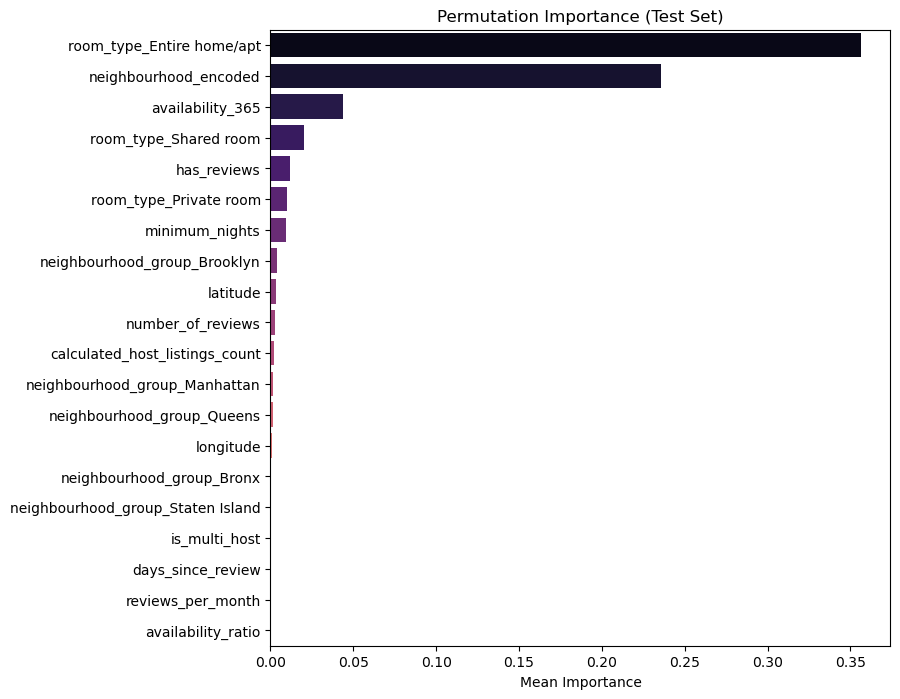

In [54]:
from sklearn.inspection import permutation_importance
perm = permutation_importance(regr, X_test, y_test, n_repeats=10, random_state=42)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=imp.head(20).values, y=imp.head(20).index, palette='magma')
plt.title('Permutation Importance (Test Set)')
plt.xlabel('Mean Importance'); plt.ylabel('')
plt.show()


### Permutation importance shows which features the model relies on most. Top predictors meaningfully reduce accuracy when shuffled, confirming their real contribution. Differences from coefficient rankings highlight non‑linear effects and multicollinearity, revealing which variables truly drive predictive performance on unseen data.

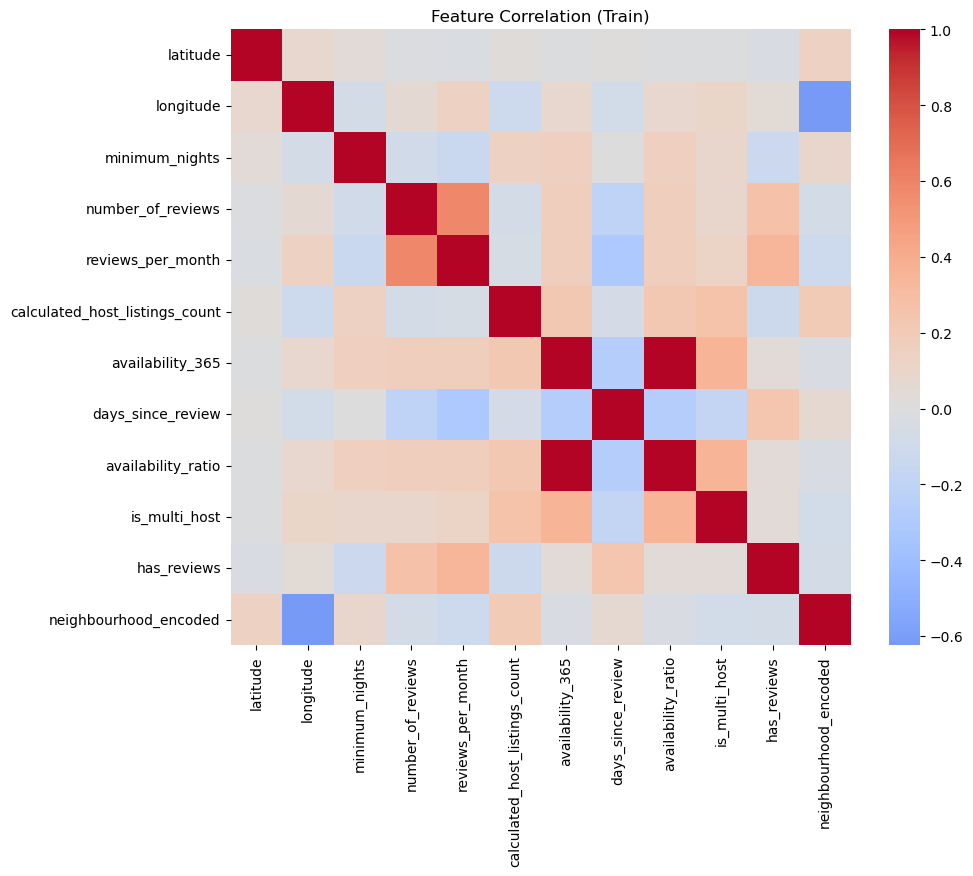

In [73]:
plt.figure(figsize=(10, 8))
sns.heatmap(X_train[num_cols_model].corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation (Train)')
plt.show()


### Permutation importance shows which features truly matter by measuring accuracy loss when each is shuffled.

# Log_price by categorical variables

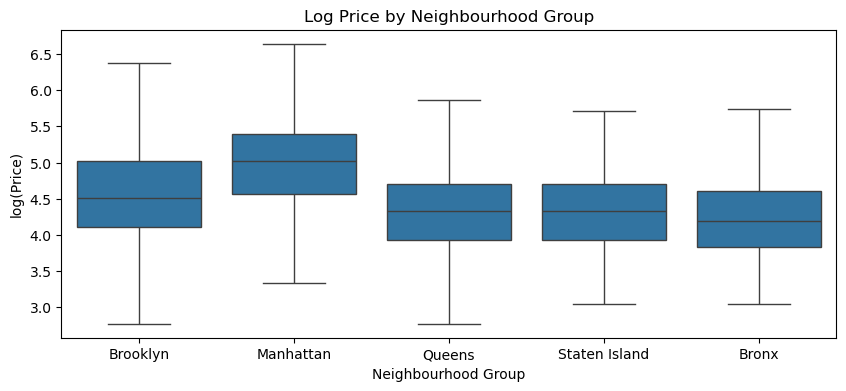

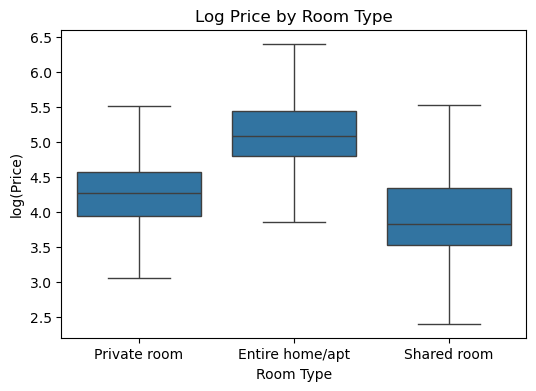

In [62]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='neighbourhood_group', y='log_price', data=df, showfliers=False)
plt.title('Log Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group'); plt.ylabel('log(Price)')
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(x='room_type', y='log_price', data=df, showfliers=False)
plt.title('Log Price by Room Type')
plt.xlabel('Room Type'); plt.ylabel('log(Price)')
plt.show()

### Neighbourhood groups show clear pricing tiers, with some boroughs consistently higher in log‑price. Room types also differ strongly: entire homes are highest, private rooms moderate, and shared rooms lowest—showing location and room type both heavily shape price levels.

# Clustering - K Means Clustering 


In [19]:
#  Select Features for Segmentation
# clustering should reveal behavioural & pricing patterns - Location can later be analysed across clusters

cluster_features = [
    'price',
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_ratio',
    'calculated_host_listings_count',
    'days_since_review',
    'is_multi_host'
]

cluster_df = df[cluster_features].copy()

In [20]:
# Scale Features - K means clustering uses euclidean distance


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

C:\Users\kapinga\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\kapinga\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\kapinga\AppData\Local\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\kapinga\AppData\Local\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\kapinga\AppData\Local\anaconda3\Lib\subpr

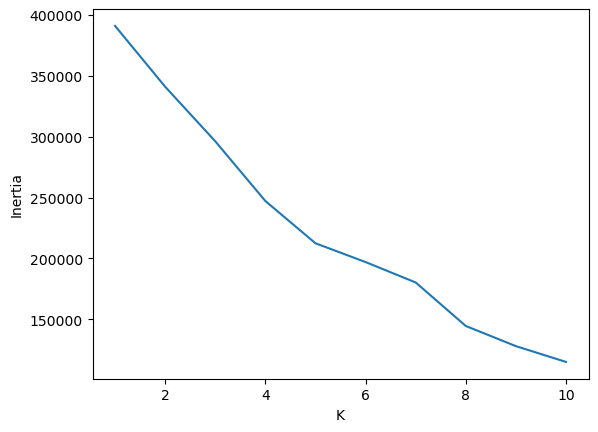

In [21]:
# Using the elbow method, find the optimal K 

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(scaled_data)
    inertia.append(km.inertia_)

plt.plot(range(1,11), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()

# Interpretation

The inertia curve drops sharply at small K and begins flattening afterward, indicating diminishing returns. The “elbow” typically marks the optimal K where additional clusters provide little improvement.

In [22]:
# Taking K = 4 from the above chart

kmeans = KMeans(n_clusters=4, random_state=42)

df['cluster'] = kmeans.fit_predict(scaled_data)

In [65]:
from sklearn.metrics import silhouette_samples

kmeans_4 = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_k4 = kmeans_4.fit_predict(X_for_kmeans)
sil_vals = silhouette_samples(X_for_kmeans, labels_k4)
avg_sil = silhouette_score(X_for_kmeans, labels_k4)

fig, ax = plt.subplots(figsize=(7, 5))
y_lower = 10
for c in sorted(np.unique(labels_k4)):
    vals = np.sort(sil_vals[labels_k4 == c])
    size = vals.shape[0]
    y_upper = y_lower + size
    color = plt.cm.tab10(c)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {c}')
    y_lower = y_upper + 10

ax.axvline(avg_sil, color='red', linestyle='--', label=f'Avg silhouette = {avg_sil:.3f}')
ax.set_title('Silhouette Plot for K=4')
ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Cluster')
ax.legend(loc='lower right'); ax.set_yticks([])
plt.tight_layout()
plt.show()


NameError: name 'X_for_kmeans' is not defined

In [23]:

cluster_summary = df.groupby('cluster')[cluster_features].mean()
print(cluster_summary)

              price  minimum_nights  number_of_reviews  reviews_per_month  \
cluster                                                                     
0        132.190703        4.837110           6.256116           0.147360   
1        153.936186        6.736296           9.888430           0.628506   
2        399.331197       49.758547           2.611111           0.367607   
3        127.115031        2.650425          89.487129           3.696958   

         availability_ratio  calculated_host_listings_count  \
cluster                                                       
0                  0.063263                        1.458280   
1                  0.304927                        3.022765   
2                  0.748732                      159.747151   
3                  0.471790                        2.287520   

         days_since_review  is_multi_host  
cluster                                    
0              1174.646665       0.115503  
1               275.614472

In [24]:
# Clustering revealed four distinct segments differentiated by pricing strategy, host professionalism, demand intensity, and listing availability. 
# The strongest performing segment was identified as low-priced, high-review velocity listings, 
# while the highest-priced listings were dominated by professional multi-property hosts.

In [25]:
# using business logic map define business segments and map to numbers

# Create mapping dictionary
cluster_labels = {
    0: "Dormant Listings",
    1: "Standard Listings",
    2: "Professional / Investment Listings",
    3: "High-Demand Value Listings"
}

# Map cluster numbers to readable segment names
df['segment'] = df['cluster'].map(cluster_labels)

# Check results
print(df[['cluster', 'segment']].head())

   cluster                     segment
0        1           Standard Listings
1        1           Standard Listings
2        1           Standard Listings
3        3  High-Demand Value Listings
4        1           Standard Listings


In [26]:
# Create prediction function for new listings 

def predict_segment(kmeans_model, scaler, input_data, feature_columns, label_mapping):

    # Convert dictionary input into DataFrame
    input_df = pd.DataFrame([input_data])

    # Ensure correct column order
    input_df = input_df[feature_columns]

    # Scale input using SAME scaler used for training
    scaled_input = scaler.transform(input_df)

    # Predict cluster
    cluster_number = kmeans_model.predict(scaled_input)[0]

    # Convert cluster number to business label
    return label_mapping[cluster_number]

# Predict segment for new listing 

new_listing = {
    'price': 250,
    'minimum_nights': 3,
    'number_of_reviews': 45,
    'reviews_per_month': 5,
    'availability_ratio': 0.30,
    'calculated_host_listings_count': 1,
    'days_since_review': 50,
    'is_multi_host': 0
}

segment_prediction = predict_segment(
    kmeans_model=kmeans,
    scaler=scaler,
    input_data=new_listing,
    feature_columns=cluster_features,
    label_mapping=cluster_labels
)

print("Predicted Segment:", segment_prediction)

In [27]:
# show segement split in dataset
print(df['segment'].value_counts())

segment
Standard Listings                     31012
High-Demand Value Listings             8702
Dormant Listings                       7766
Professional / Investment Listings     1404
Name: count, dtype: int64


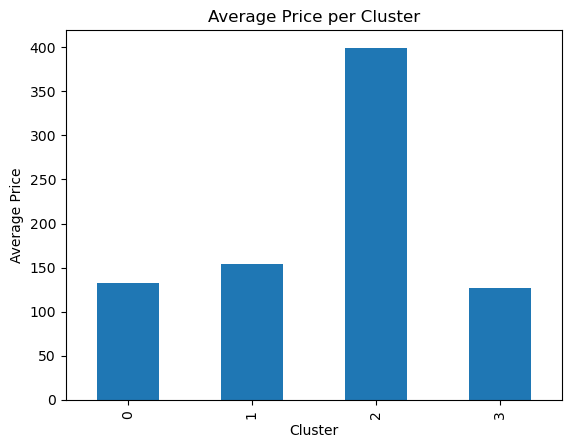

In [28]:
# Fit KMeans (using 4 clusters as before)
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

# Calculate average price per cluster
cluster_price = df.groupby('cluster')['price'].mean()

# Plot chart
plt.figure()
cluster_price.plot(kind='bar')

plt.xlabel("Cluster")
plt.ylabel("Average Price")
plt.title("Average Price per Cluster")

plt.show()


### Clusters show clear price differentiation: some groups represent higher‑priced areas, while others contain more affordable listings. This indicates K‑Means effectively captures meaningful market segments tied to spatial and attribute patterns.

In [29]:
# Import libraries for DBScan
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X_scaled = scaler.fit_transform(X)
dbscan = DBSCAN(eps=0.8, min_samples=10)
df['db_cluster'] = dbscan.fit_predict(X_scaled)

In [30]:
dbscan = DBSCAN(eps=2.4, min_samples=10) # min_samples is the minimum required to form clusters & eps is neighbourhood radius
df['db_cluster'] = dbscan.fit_predict(X_scaled)

In [31]:
print(df['db_cluster'].value_counts())

db_cluster
 1     9701
 3     8130
 0     7968
 4     6267
 5     2885
 7     2630
 6     2127
 8     1712
 2     1658
 12    1380
 17     686
 9      518
-1      415
 13     348
 18     347
 11     296
 19     282
 27     200
 30     199
 15     153
 22     142
 16     138
 10     126
 20     123
 29     120
 14     119
 23      69
 21      43
 26      39
 28      28
 24      12
 25      12
 31      11
Name: count, dtype: int64


In [32]:
noise_count = sum(df['db_cluster'] == -1)
print("Number of noise points:", noise_count)

Number of noise points: 415


In [37]:
from sklearn.metrics import silhouette_score

# Remove noise for silhouette calculation
mask = df['db_cluster'] != -1
clusters = df.loc[mask, 'db_cluster'].unique()

# Silhouette score requires at least 2 clusters
if len(clusters) > 1:
    score = silhouette_score(X_scaled[mask], df.loc[mask, 'db_cluster'])
    print("Silhouette Score:", score)
else:
    print("Not enough clusters (need at least 2 non-noise clusters).")


Silhouette Score: 0.19873974694653201


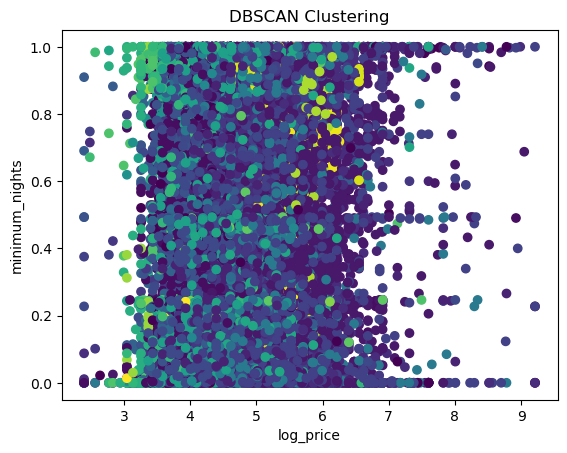

In [36]:
plt.figure()
plt.scatter(df['log_price'], df['availability_ratio'], 
            c=df['db_cluster'])

plt.xlabel("log_price")
plt.ylabel("minimum_nights")
plt.title("DBSCAN Clustering")
plt.show()

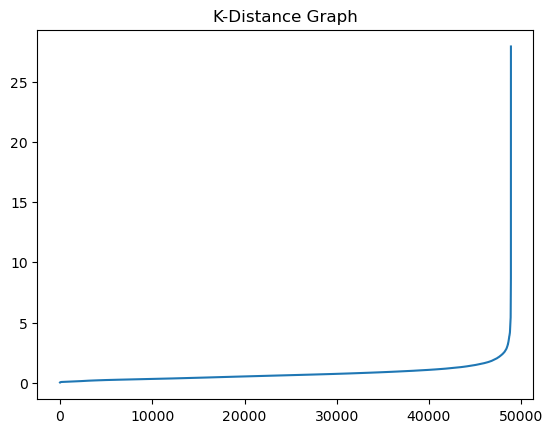

In [35]:
# tune eps
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:,9])
plt.plot(distances)
plt.title("K-Distance Graph")
plt.show()

# K-means vs DBScan VISUALIZATION 

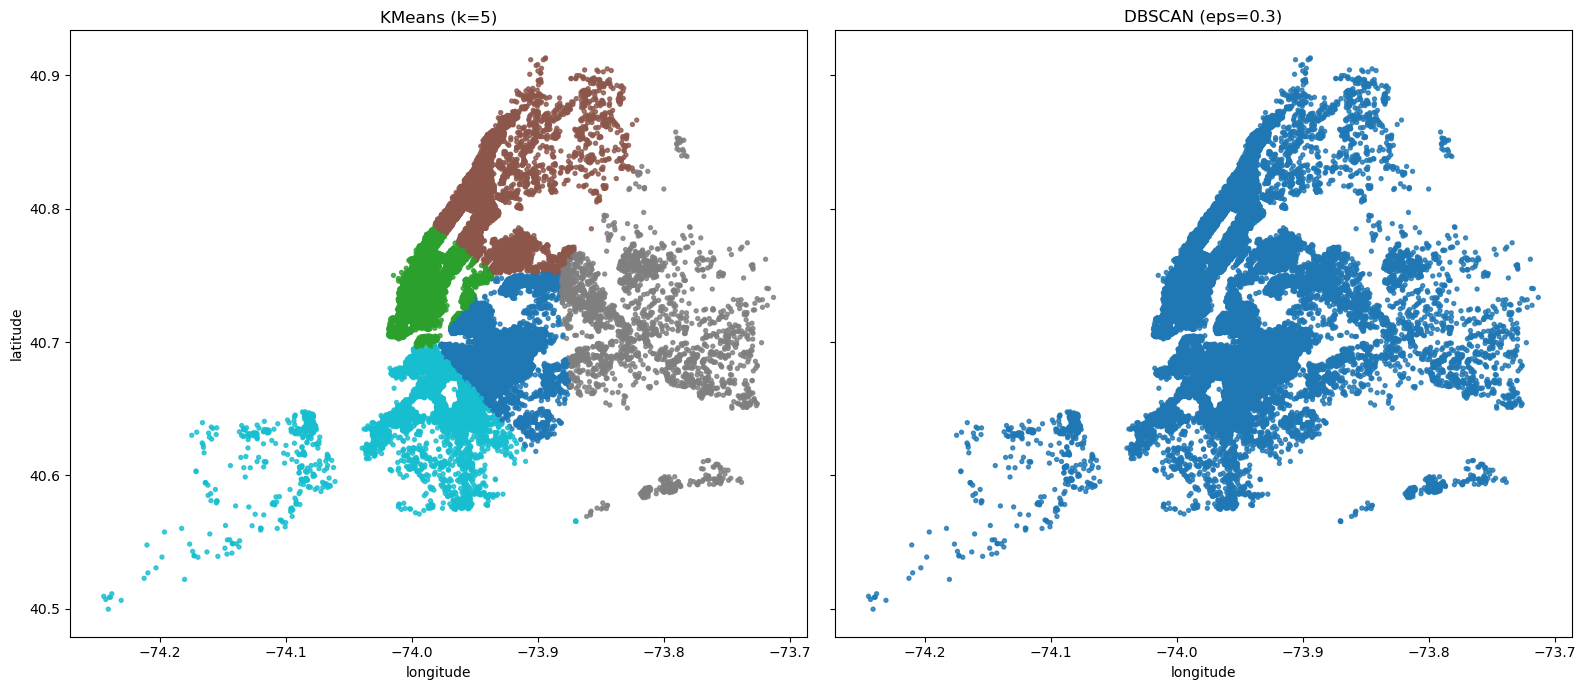

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN

# Keep only valid coordinates
dfc = df[['longitude', 'latitude']].dropna().copy()
X = dfc[['longitude', 'latitude']].to_numpy()

# --- 1) KMeans Clustering (k=5) ---
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
dfc['kmeans_label'] = kmeans.fit_predict(X)

# --- 2) DBSCAN Clustering ---
# eps=0.3 roughly equals ~0.3 degrees (~1–2 km), adjust as needed
dbscan = DBSCAN(eps=0.3, min_samples=30)
dfc['dbscan_label'] = dbscan.fit_predict(X)

# --- 3) Plot KMeans + DBSCAN side by side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# ========= KMEANS PLOT =========
axes[0].scatter(
    dfc['longitude'], dfc['latitude'],
    c=dfc['kmeans_label'], cmap='tab10',
    s=8, alpha=0.8
)
axes[0].set_title("KMeans (k=5)")
axes[0].set_xlabel("longitude")
axes[0].set_ylabel("latitude")

# ========= DBSCAN PLOT =========
# DBSCAN uses -1 for noise → plot noise as grey
colors = dfc['dbscan_label']
axes[1].scatter(
    dfc['longitude'], dfc['latitude'],
    c=colors,
    cmap='tab10',
    s=8, alpha=0.8
)

# Grey color for DBSCAN noise
axes[1].scatter(
    dfc.loc[dfc['dbscan_label'] == -1, 'longitude'],
    dfc.loc[dfc['dbscan_label'] == -1, 'latitude'],
    c='lightgrey', s=8, alpha=0.6, label="noise"
)
axes[1].set_title("DBSCAN (eps=0.3)")
axes[1].set_xlabel("longitude")

plt.tight_layout()
plt.show()



### The comparasion reveals that KMeans produces clean, fixed clusters, while DBSCAN reveals natural density‑based shapes and isolates sparse areas as noise. DBSCAN’s noise points highlight regions without strong spatial grouping, showing more nuanced structure than KMeans.